In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from scipy.signal import butter, filtfilt, hilbert
from scipy.interpolate import interp1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Set plot style
sns.set(context='talk', style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Configurable parameters (aligned with papers)
SRATE = 1000  # Sampling rate from papers
CHANNELS_OF_INTEREST = ['C3', 'C4']  # Motor cortex channels (papers Fig 3)
MIN_TRIALS = 10  # Minimum for analysis
MIN_SIGNAL_LEN = 5000  # For MFDFA
MIN_SCALES = 5  # For MFDFA
ARTIFACT_THRESHOLD = 100  # Amplitude threshold from papers
FEEDBACK_START = int(2000 / 1000 * SRATE)  # 2000 ms (papers: feedback start)
FEEDBACK_END = int(4000 / 1000 * SRATE)    # 4000 ms

In [4]:
# Butterworth filters (papers: 0.1-200 Hz online, but we use for ERD/MFDFA)
_b, _a = butter(4, [8/(SRATE/2), 30/(SRATE/2)], btype='band')  # General bandpass
_bhp, _ahp = butter(4, 1/(SRATE/2), btype='high')  # High-pass
b_alpha, a_alpha = butter(4, [8/(SRATE/2), 14/(SRATE/2)], btype='band')  # Alpha for ERD

In [5]:
def bandpass(data):
    return filtfilt(_b, _a, data, axis=-1, padlen=150)

def highpass(data):
    return filtfilt(_bhp, _ahp, data, axis=-1, padlen=150)

# Channel index lookup (using chaninfo.label from papers)
def get_channel_index(chaninfo, label):
    labels = chaninfo.label
    try:
        return np.where(labels == label)[0][0]
    except IndexError:
        print(f"Channel {label} not found.")
        return None

In [6]:
GLOB_PATTERN = 'S*_Session_1.mat'  # Pattern for dynamic discovery
MAX_FILES = 20  # Limit for glob results
MIN_FILES_REQUIRED = 1  # Minimum files to proceed

# Discover files: Try glob first, fallback to hardcoded
files = sorted(glob.glob(GLOB_PATTERN))[:MAX_FILES]
if not files:
    files = HARDCODED_FILES
existing = [f for f in files if os.path.exists(f)]

print(f'Found {len(existing)} / {len(files)} files')
if len(existing) < MIN_FILES_REQUIRED:
    raise FileNotFoundError('No sufficient .mat files found. Place them next to this notebook and rerun.')


Found 8 / 8 files


In [7]:
trials_dict = {}
trial_data_dict = {}
chaninfo_dict = {}

for f in files:
    sid = os.path.basename(f).split('_')[0]
    mat = sio.loadmat(f, squeeze_me=True, struct_as_record=False)
    if 'BCI' not in mat:
        print(f"Skipping {f}: No 'BCI' structure.")
        continue
    BCI = mat['BCI']
    trials = [t for t in BCI.data if t is not None]
    trial_data = BCI.TrialData if hasattr(BCI, 'TrialData') else []
    chaninfo = BCI.chaninfo if hasattr(BCI, 'chaninfo') else None
    trials_dict[sid] = trials
    trial_data_dict[sid] = trial_data
    chaninfo_dict[sid] = chaninfo
    print(f"Loaded {sid}: {len(trials)} trials")

# Filter artifacts (using artifact flag and amplitude, as per papers)
for sid in list(trials_dict.keys()):
    clean_trials = []
    clean_data = []
    for i, trial in enumerate(trials_dict[sid]):
        if i >= len(trial_data_dict[sid]):
            continue
        tdata = trial_data_dict[sid][i]
        if hasattr(tdata, 'artifact') and tdata.artifact == 1:
            continue  # Skip flagged artifacts (papers' method)
        filtered = bandpass(trial)
        if np.max(np.abs(filtered)) > ARTIFACT_THRESHOLD:
            continue  # Amplitude threshold (papers' validation)
        clean_trials.append(trial)
        clean_data.append(tdata)
    trials_dict[sid] = clean_trials
    trial_data_dict[sid] = clean_data
    print(f"{sid}: {len(clean_trials)} clean trials after filtering")

Loaded S1: 450 trials
Loaded S2: 450 trials
Loaded S3: 450 trials
Loaded S4: 450 trials
Loaded S5: 450 trials
Loaded S6: 450 trials
Loaded S7: 450 trials
Loaded S8: 450 trials
S1: 449 clean trials after filtering
S2: 447 clean trials after filtering
S3: 1 clean trials after filtering
S4: 403 clean trials after filtering
S5: 411 clean trials after filtering
S6: 432 clean trials after filtering
S7: 449 clean trials after filtering
S8: 439 clean trials after filtering


In [8]:
def erd_one(sid, task, target, ch=8):  # ch=8 for C3 as default
    trials = trials_dict.get(sid, [])
    trial_data = trial_data_dict.get(sid, [])
    
    sigs = []
    for i, tr in enumerate(trials):
        if i >= len(trial_data):
            continue
        td = trial_data[i]
        if hasattr(td, 'tasknumber') and hasattr(td, 'targetnumber'):
            if td.tasknumber == task and td.targetnumber == target:
                if tr is not None and tr.shape[0] > ch:
                    sigs.append(tr[ch])
    
    if not sigs:
        return None, None
    
    # Handle variable lengths: interpolate to median length
    lengths = [len(s) for s in sigs]
    target_len = int(np.median(lengths))
    interpolated_sigs = []
    for sig in sigs:
        if len(sig) < target_len * 0.8:  # Skip very short signals
            continue
        x_old = np.linspace(0, len(sig)-1, len(sig))
        x_new = np.linspace(0, len(sig)-1, target_len)
        f = interp1d(x_old, sig, kind='linear', fill_value='extrapolate')
        interpolated_sigs.append(f(x_new))
    
    if not interpolated_sigs:
        return None, None
    
    avg = np.mean(interpolated_sigs, axis=0)
    
    # Apply filters and compute envelope
    filtered = highpass(avg)
    alpha_sig = filtfilt(b_alpha, a_alpha, filtered)
    env = np.abs(hilbert(alpha_sig))**2
    
    # Time vector: -2000 to 4000 ms
    t = np.linspace(-2000, 4000, len(env))
    
    # Baseline correction (-1000 to 0 ms)
    baseline_mask = (t >= -1000) & (t <= 0)
    if np.sum(baseline_mask) > 0:
        baseline_power = np.mean(env[baseline_mask])
        erd = 100 * (env - baseline_power) / baseline_power
    else:
        erd = env  # Fallback if no baseline
    
    return t, erd

print("erd_one function defined successfully.")

erd_one function defined successfully.


📊 Computing ERD analysis...
✅ Right: 7 subjects processed (truncated to 6861 samples)
✅ Left: 8 subjects processed (truncated to 7041 samples)
✅ Up: 7 subjects processed (truncated to 7081 samples)
✅ Down: 7 subjects processed (truncated to 7281 samples)


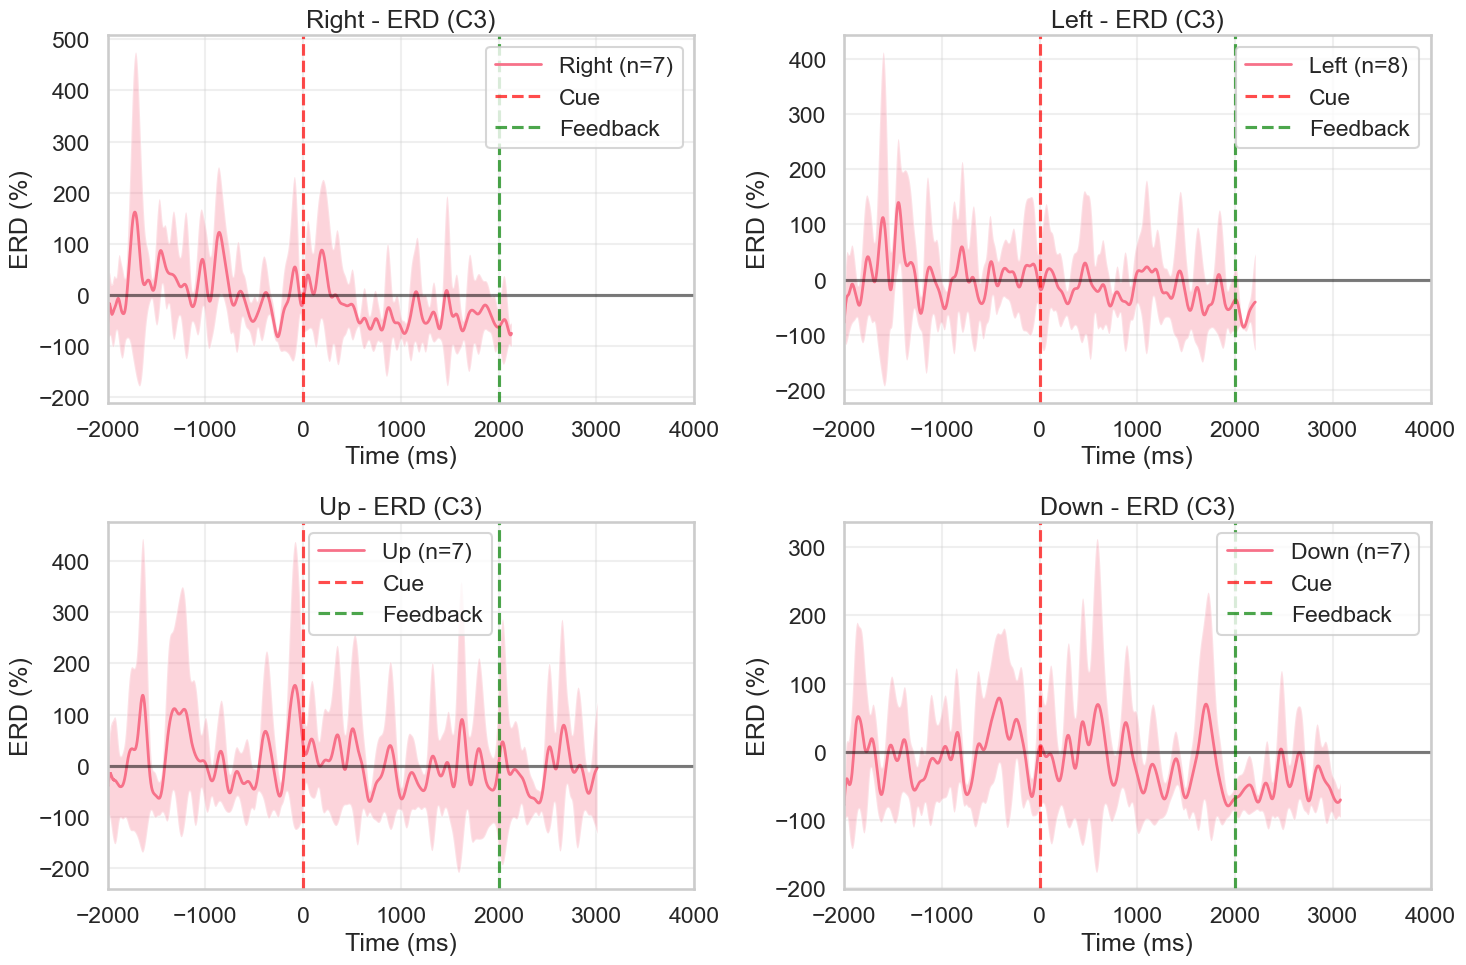

✅ ERD analysis completed


In [9]:
# Updated ERD Analysis with proper time vector handling
print("📊 Computing ERD analysis...")

# Define erd_one if not already (from previous fix)
# [Insert the erd_one function definition here if needed]

conditions = [
    ('Right', 1, 1),
    ('Left', 1, 2), 
    ('Up', 2, 3),
    ('Down', 2, 4)
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, (condition, tsk, tgt) in enumerate(conditions):
    ax = axes[idx]
    
    all_erd = []
    common_t = None  # Initialize as None instead of empty list
    
    for sid in trials_dict:
        t, e = erd_one(sid, tsk, tgt)
        if e is not None:
            all_erd.append(e)
            if common_t is None:  # Assign from first successful analysis (safe None check)
                common_t = t
    
    if all_erd and common_t is not None:
        # KEY FIX: Truncate all ERD signals to the minimum length
        min_erd_length = min(len(erd) for erd in all_erd)
        truncated_erd = [erd[:min_erd_length] for erd in all_erd]
        time_vec = common_t[:min_erd_length]  # Truncate the common time vector
        
        # Now averaging will work without error
        mean_erd = np.mean(truncated_erd, axis=0)
        std_erd = np.std(truncated_erd, axis=0)
        
        # Plot
        ax.plot(time_vec, mean_erd, linewidth=2, label=f'{condition} (n={len(all_erd)})')
        ax.fill_between(time_vec, mean_erd - std_erd, mean_erd + std_erd, alpha=0.3)
        
        # Add reference lines
        ax.axhline(0, color='black', linestyle='-', alpha=0.5)
        ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Cue')
        ax.axvline(2000, color='green', linestyle='--', alpha=0.7, label='Feedback')
        
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('ERD (%)')
        ax.set_title(f'{condition} - ERD (C3)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-2000, 4000)
        
        print(f"✅ {condition}: {len(all_erd)} subjects processed (truncated to {min_erd_length} samples)")
    else:
        ax.text(0.5, 0.5, f'No data for {condition}', 
                transform=ax.transAxes, ha='center', va='center')
        ax.set_title(f'{condition} - No Data')
        print(f"❌ {condition}: No valid data")

plt.tight_layout()
plt.show()

print("✅ ERD analysis completed")


In [10]:
import numpy as np
from scipy.signal import filtfilt
from scipy.signal import hilbert
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Updated Logistic Regression (always returns 5 values)
def logistic_regression_classification(trials, trial_data, task=1, targets=[1, 2], min_trials=10, feedback_start=2000, feedback_end=4000, b_alpha=None, a_alpha=None):
    features = []
    labels = []
    for i, tr in enumerate(trials):
        if i >= len(trial_data):
            continue
        td = trial_data[i]
        if td.tasknumber == task and td.targetnumber in targets:
            feedback = tr[:, feedback_start:feedback_end]
            alpha_power = np.mean(np.abs(hilbert(filtfilt(b_alpha, a_alpha, feedback, axis=1)))**2, axis=1)
            features.append(alpha_power)
            labels.append(td.targetnumber - 1)  # Map to 0/1 for binary
    
    if len(features) < min_trials:
        return None, None, None, None, None  # Fixed: Return 5 Nones
    
    X = np.array(features)
    y = np.array(labels)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    logreg = LogisticRegression(max_iter=200)
    scores = cross_val_score(logreg, X_scaled, y, cv=5)
    y_pred = cross_val_predict(logreg, X_scaled, y, cv=5)
    y_prob = cross_val_predict(logreg, X_scaled, y, cv=5, method='predict_proba')[:, 1]  # For ROC
    return np.mean(scores), scores, y, y_pred, y_prob

In [11]:
# Updated SVM (always returns 5 values)
import numpy as np
from scipy.signal import hilbert, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC  # <-- Required for SVM

def svm_classification(trials, trial_data, task=1, targets=[1, 2], min_trials=10, feedback_start=2000, feedback_end=4000, b_alpha=None, a_alpha=None):
    features = []
    labels = []
    for i, tr in enumerate(trials):
        if i >= len(trial_data):
            continue
        td = trial_data[i]
        if td.tasknumber == task and td.targetnumber in targets:
            feedback = tr[:, feedback_start:feedback_end]
            alpha_power = np.mean(np.abs(hilbert(filtfilt(b_alpha, a_alpha, feedback, axis=1)))**2, axis=1)
            features.append(alpha_power)
            labels.append(td.targetnumber - 1)  # Map to 0/1 for binary
    
    if len(features) < min_trials:
        return None, None, None, None, None  # Fixed: Return 5 Nones
    
    X = np.array(features)
    y = np.array(labels)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    svm = SVC(kernel='linear', probability=True)  # Enable probabilities
    scores = cross_val_score(svm, X_scaled, y, cv=5)
    y_pred = cross_val_predict(svm, X_scaled, y, cv=5)
    y_prob = cross_val_predict(svm, X_scaled, y, cv=5, method='decision_function')  # For ROC
    return np.mean(scores), scores, y, y_pred, y_prob

📊 Computing classifications for all subjects...


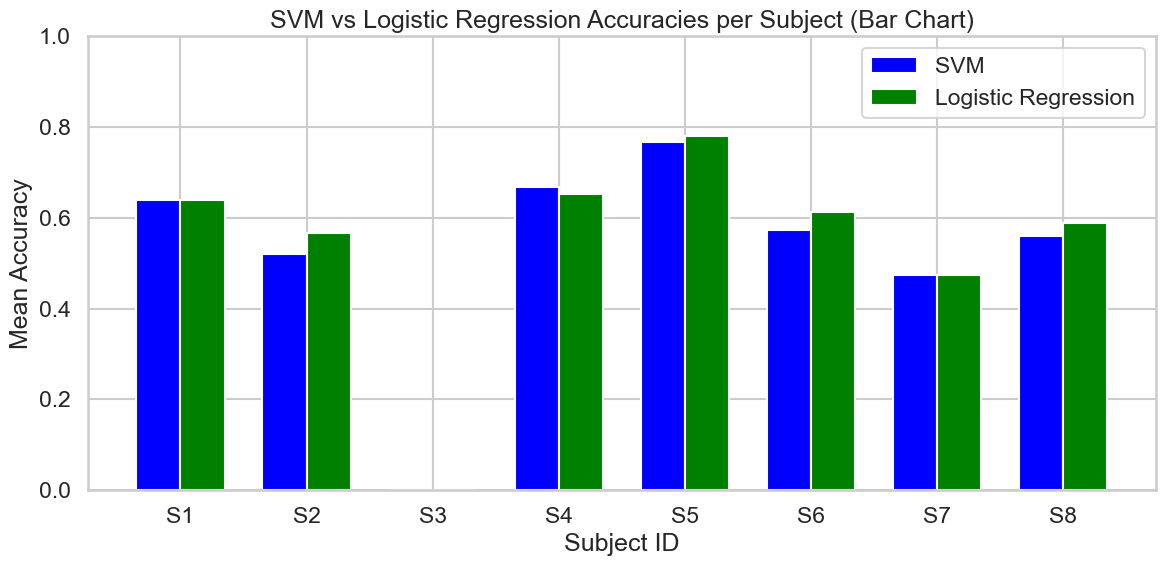

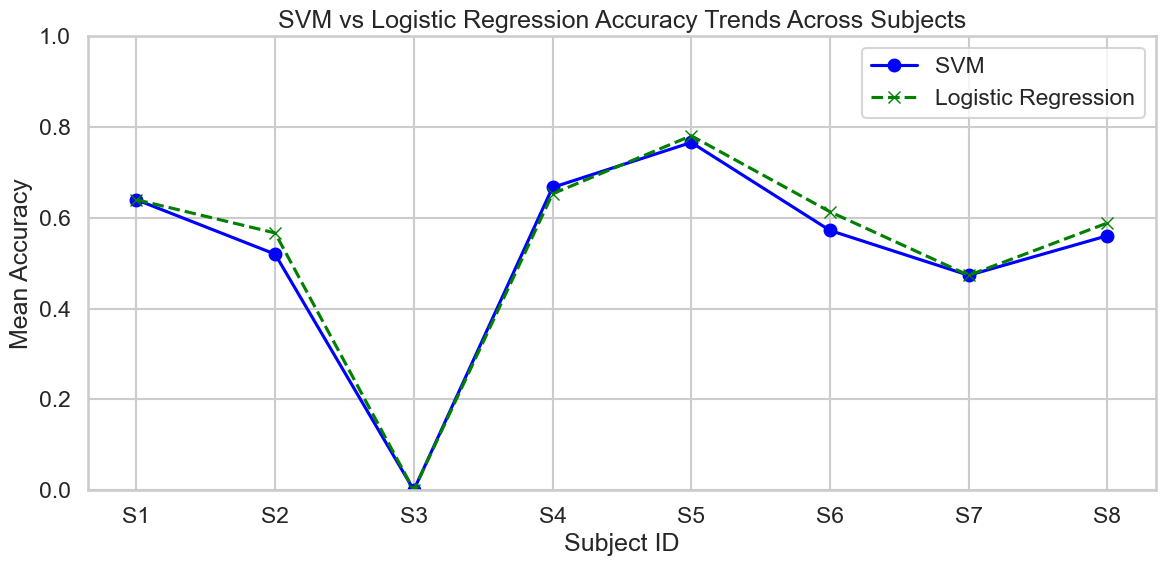

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# (Your logistic_regression_classification and svm_classification functions are already defined)

# Compute classifications and collect means
subject_ids = sorted(trials_dict.keys())  # Assumes trials_dict is loaded
svm_means = []
logreg_means = []

print("📊 Computing classifications for all subjects...")
for sid in subject_ids:
    
    logreg_results = logistic_regression_classification(
        trials_dict[sid], trial_data_dict[sid], b_alpha=b_alpha, a_alpha=a_alpha,
        feedback_start=FEEDBACK_START, feedback_end=FEEDBACK_END
    )
    svm_results = svm_classification(
        trials_dict[sid], trial_data_dict[sid], b_alpha=b_alpha, a_alpha=a_alpha,
        feedback_start=FEEDBACK_START, feedback_end=FEEDBACK_END
    )
    
    if logreg_results[0] is not None:
        logreg_means.append(logreg_results[0])  # Mean accuracy
    else:
        logreg_means.append(0)  # Placeholder
        print(f"Warning: Insufficient trials for LogReg on {sid}")
    
    if svm_results[0] is not None:
        svm_means.append(svm_results[0])
    else:
        svm_means.append(0)
        print(f"Warning: Insufficient trials for SVM on {sid}")

# Bar Chart: Per-subject comparison
x = np.arange(len(subject_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, svm_means, width, label='SVM', color='blue')
ax.bar(x + width/2, logreg_means, width, label='Logistic Regression', color='green')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Mean Accuracy')
ax.set_title('SVM vs Logistic Regression Accuracies per Subject (Bar Chart)')
ax.set_xticks(x)
ax.set_xticklabels(subject_ids)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Trend Graph: Accuracy trends across subjects
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(subject_ids, svm_means, marker='o', linestyle='-', color='blue', label='SVM')
ax.plot(subject_ids, logreg_means, marker='x', linestyle='--', color='green', label='Logistic Regression')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Mean Accuracy')
ax.set_title('SVM vs Logistic Regression Accuracy Trends Across Subjects')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [13]:
# MFDFA for different channels
def mfdfa(signal, scales=None, qs=np.arange(-5, 6), order=1):
    if scales is None:
        scales = np.logspace(2, 3, 12).astype(int)
    N = len(signal)
    profile = np.cumsum(signal - np.mean(signal))
    Fq = np.zeros((len(scales), len(qs)))
    for i, scale in enumerate(scales):
        Ns = N // scale
        rms = []
        for v in range(Ns):
            seg = profile[v*scale:(v+1)*scale]
            x = np.arange(len(seg))
            coeffs = np.polyfit(x, seg, order)
            trend = np.polyval(coeffs, x)
            detrended = seg - trend
            rms.append(np.sqrt(np.mean(detrended**2)))
        rms = np.array(rms)
        for j, q in enumerate(qs):
            if q == 0:
                Fq[i, j] = np.exp(0.5 * np.mean(np.log(rms**2)))
            else:
                Fq[i, j] = (np.mean(rms**q)) ** (1/q)
    H = []
    for j in range(len(qs)):
        valid = Fq[:, j] > 0
        if np.sum(valid) > 3:
            coeffs = np.polyfit(np.log2(scales[valid]), np.log2(Fq[valid, j]), 1)
            H.append(coeffs[0])
        else:
            H.append(np.nan)
    return np.array(H)


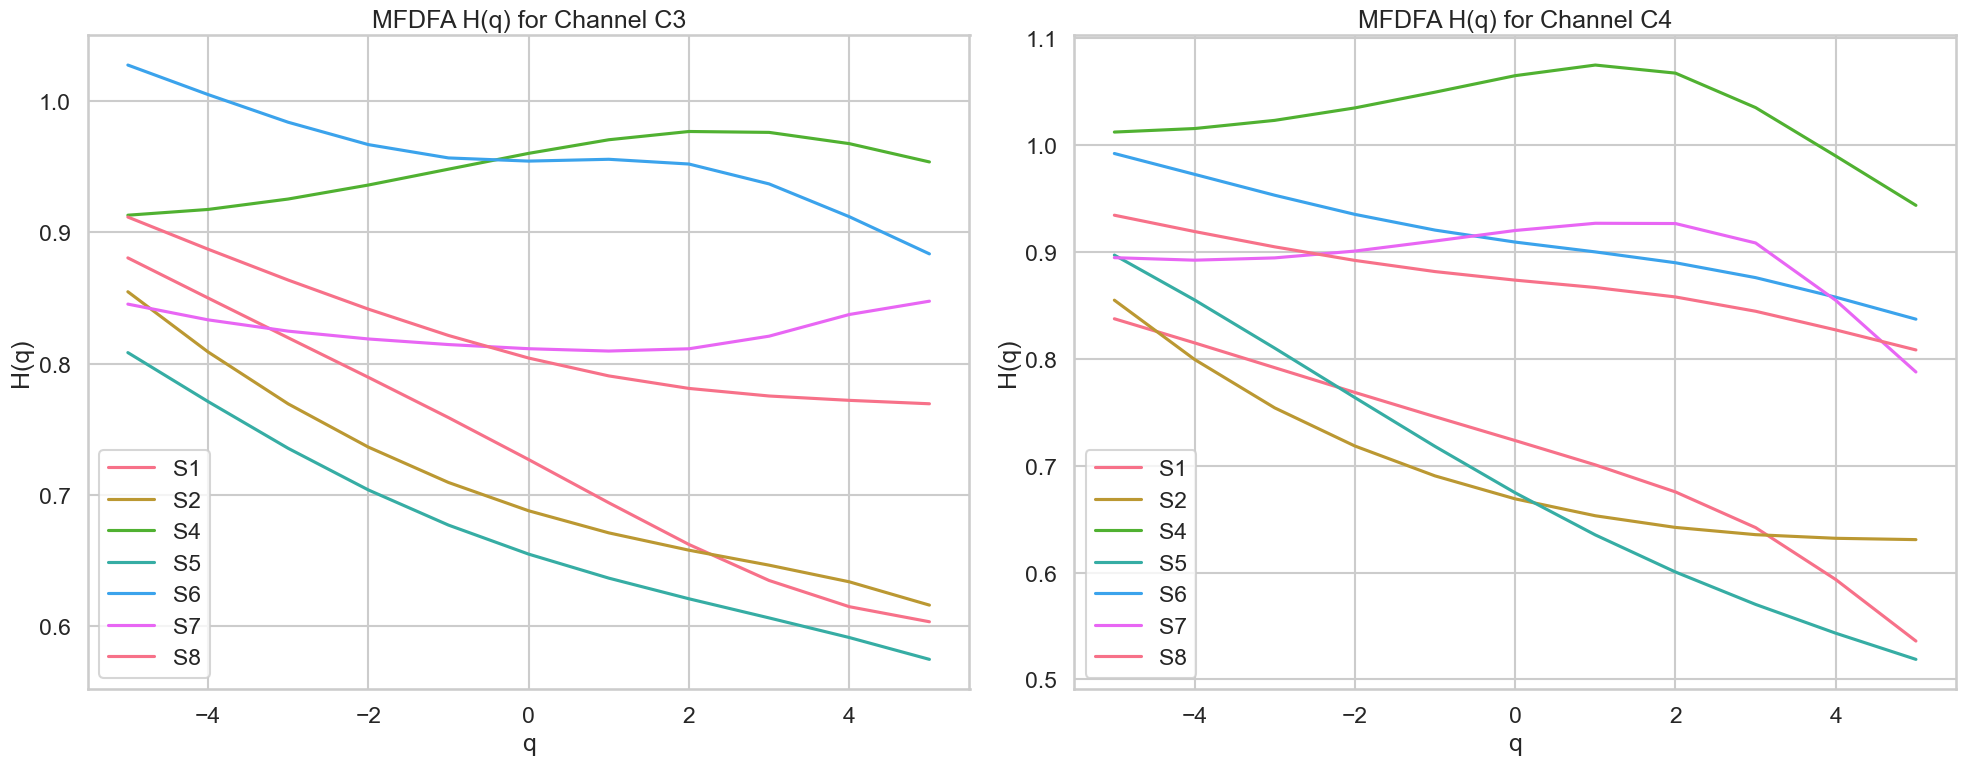

In [14]:
# Plot MFDFA for C3 and C4
fig_mfdfa, axs_mfdfa = plt.subplots(1, 2, figsize=(20, 8))
for ch_idx, chan in enumerate(CHANNELS_OF_INTEREST):
    ax = axs_mfdfa[ch_idx]
    for sid in trials_dict:
        ch_index = get_channel_index(chaninfo_dict[sid], chan)
        if ch_index is None:
            continue
        sigs = [trial[ch_index, FEEDBACK_START:FEEDBACK_END] for trial in trials_dict[sid]]
        if not sigs:
            continue
        signal = np.concatenate(sigs)
        if len(signal) < MIN_SIGNAL_LEN:
            continue
        signal = highpass(signal)
        H = mfdfa(signal)
        ax.plot(np.arange(-5, 6), H, label=sid)
    ax.set_title(f'MFDFA H(q) for Channel {chan}')
    ax.set_xlabel('q')
    ax.set_ylabel('H(q)')
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()

Assessing multifractality from MFDFA H(q)...
S1: H(q) variation = 0.29 (strong if > 0.1)
S2: H(q) variation = 0.23 (strong if > 0.1)
S3: No valid MFDFA data
S4: H(q) variation = 0.07 (strong if > 0.1)
S5: H(q) variation = 0.31 (strong if > 0.1)
S6: H(q) variation = 0.15 (strong if > 0.1)
S7: H(q) variation = 0.05 (strong if > 0.1)
S8: H(q) variation = 0.13 (strong if > 0.1)

Running classifications with adaptive SVM kernel based on multifractality...
S1: Multifractality strength 0.29 → Using SVM kernel: rbf
S2: Multifractality strength 0.23 → Using SVM kernel: rbf
Skipping classification for S3: Insufficient trials (1)
S4: Multifractality strength 0.07 → Using SVM kernel: linear
S5: Multifractality strength 0.31 → Using SVM kernel: rbf
S6: Multifractality strength 0.15 → Using SVM kernel: rbf
S7: Multifractality strength 0.05 → Using SVM kernel: linear
S8: Multifractality strength 0.13 → Using SVM kernel: rbf


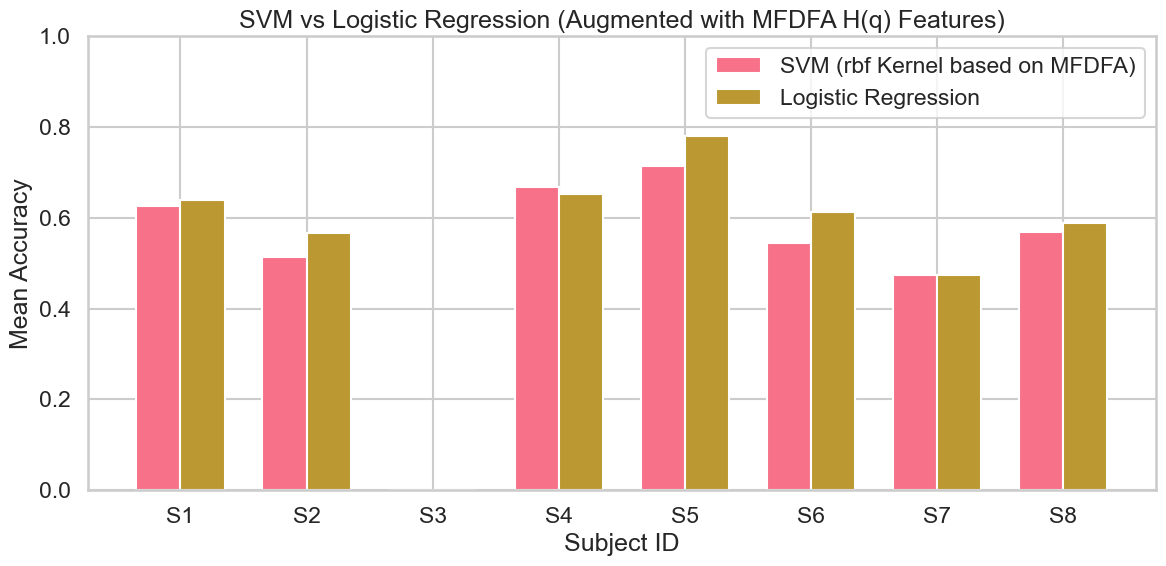

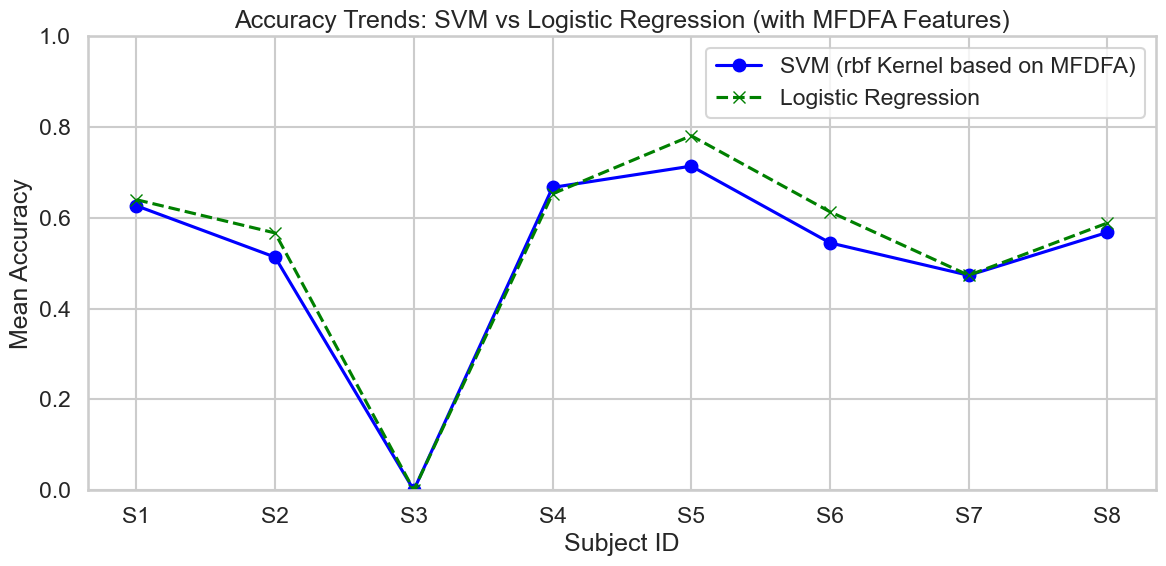

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Assuming your existing MFDFA computation is run (from your notebook cell)
# This code continues after plotting MFDFA for C3 and C4
# We'll use H(q) from CHANNELS_OF_INTEREST to check multifractality and adapt SVM kernel

# Step 1: Extract H(q) from your existing MFDFA results (assume you have a dict like mfdfa_results per sid/channel)
# For simplicity, compute average H(q) across C3/C4 for each subject
mfdfa_strength = {}
VAR_THRESH = 0.1  # Threshold for strong multifractality (adjust based on your data; e.g., if H(q) range > 0.1, use RBF)

print("Assessing multifractality from MFDFA H(q)...")
for sid in trials_dict:
    avg_H = []
    for chan in CHANNELS_OF_INTEREST:
        ch_index = get_channel_index(chaninfo_dict[sid], chan)
        if ch_index is None:
            continue
        sigs = [trial[ch_index, FEEDBACK_START:FEEDBACK_END] for trial in trials_dict[sid]]
        if not sigs:
            continue
        signal = np.concatenate(sigs)
        if len(signal) < MIN_SIGNAL_LEN:
            continue
        signal = highpass(signal)
        H = mfdfa(signal)
        avg_H.append(H)
    
    if avg_H:
        avg_Hq = np.mean(avg_H, axis=0)
        strength = np.nanmax(avg_Hq) - np.nanmin(avg_Hq)  # Range as measure of variation (multifractality)
        mfdfa_strength[sid] = strength
        print(f"{sid}: H(q) variation = {strength:.2f} (strong if > {VAR_THRESH})")
    else:
        mfdfa_strength[sid] = 0
        print(f"{sid}: No valid MFDFA data")

# Step 2: Adaptive SVM classification (integrate with your existing loop)
# Add this inside your classification computation loop (after computing alpha_power)
# Example augmentation in svm_classification (modify your function or add in loop)

svm_means = []  # Collect means for visualization
logreg_means = []

print("\nRunning classifications with adaptive SVM kernel based on multifractality...")
for sid in subject_ids:
    features = []
    labels = []
    for i, tr in enumerate(trials_dict[sid]):
        if i >= len(trial_data_dict[sid]):
            continue
        td = trial_data_dict[sid][i]
        if td.tasknumber == 1 and td.targetnumber in [1, 2]:  # Your task filter
            feedback = tr[:, FEEDBACK_START:FEEDBACK_END]
            alpha_power = np.mean(np.abs(hilbert(filtfilt(b_alpha, a_alpha, feedback, axis=1)))**2, axis=1)
            
            # Augment with MFDFA H(q) (average across channels)
            Hq = np.zeros(len(np.arange(-5, 6)))  # Placeholder
            num_chans = 0
            for chan in CHANNELS_OF_INTEREST:
                ch_index = get_channel_index(chaninfo_dict[sid], chan)
                if ch_index is None:
                    continue
                sig = tr[ch_index, FEEDBACK_START:FEEDBACK_END]
                if len(sig) < MIN_SIGNAL_LEN:
                    continue
                sig = highpass(sig)
                H = mfdfa(sig)
                Hq += H
                num_chans += 1
            if num_chans > 0:
                Hq /= num_chans
            
            # Combine alpha_power and H(q)
            combined_feat = np.concatenate([alpha_power, Hq])
            features.append(combined_feat)
            labels.append(td.targetnumber - 1)
    
    if len(features) < MIN_TRIALS:
        svm_means.append(0)
        logreg_means.append(0)
        print(f"Skipping classification for {sid}: Insufficient trials ({len(features)})")
        continue
    
    X = np.array(features)
    y = np.array(labels)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Logistic Regression (baseline)
    logreg = LogisticRegression(max_iter=200)
    logreg_scores = cross_val_score(logreg, X_scaled, y, cv=5)
    logreg_means.append(np.mean(logreg_scores))
    
    # Adaptive SVM kernel based on multifractality
    strength = mfdfa_strength.get(sid, 0)
    kernel = 'rbf' if strength > VAR_THRESH else 'linear'
    print(f"{sid}: Multifractality strength {strength:.2f} → Using SVM kernel: {kernel}")
    svm = SVC(kernel=kernel, probability=True)
    svm_scores = cross_val_score(svm, X_scaled, y, cv=5)
    svm_means.append(np.mean(svm_scores))

# Visualization: Bar and Trend Graphs (using your existing plot code)
x = np.arange(len(subject_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, svm_means, width, label=f'SVM ({kernel} Kernel based on MFDFA)')
ax.bar(x + width/2, logreg_means, width, label='Logistic Regression')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Mean Accuracy')
ax.set_title('SVM vs Logistic Regression (Augmented with MFDFA H(q) Features)')
ax.set_xticks(x)
ax.set_xticklabels(subject_ids)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(subject_ids, svm_means, marker='o', linestyle='-', color='blue', label=f'SVM ({kernel} Kernel based on MFDFA)')
ax.plot(subject_ids, logreg_means, marker='x', linestyle='--', color='green', label='Logistic Regression')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Accuracy Trends: SVM vs Logistic Regression (with MFDFA Features)')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


Assessing multifractality from MFDFA H(q) for C3 and C4...
S1: H(q) variation (multifractality strength) = 0.29 (strong if > 0.1)
S2: H(q) variation (multifractality strength) = 0.23 (strong if > 0.1)
S3: No valid MFDFA data for multifractality check
S4: H(q) variation (multifractality strength) = 0.07 (strong if > 0.1)
S5: H(q) variation (multifractality strength) = 0.31 (strong if > 0.1)
S6: H(q) variation (multifractality strength) = 0.15 (strong if > 0.1)
S7: H(q) variation (multifractality strength) = 0.05 (strong if > 0.1)
S8: H(q) variation (multifractality strength) = 0.13 (strong if > 0.1)

Running classifications with adaptive SVM kernel based on multifractality...
S1: Multifractality strength 0.29 → Using SVM kernel: rbf
S2: Multifractality strength 0.23 → Using SVM kernel: rbf
Skipping S3: Insufficient trials (1)
S4: Multifractality strength 0.07 → Using SVM kernel: linear
S5: Multifractality strength 0.31 → Using SVM kernel: rbf
S6: Multifractality strength 0.15 → Using SV

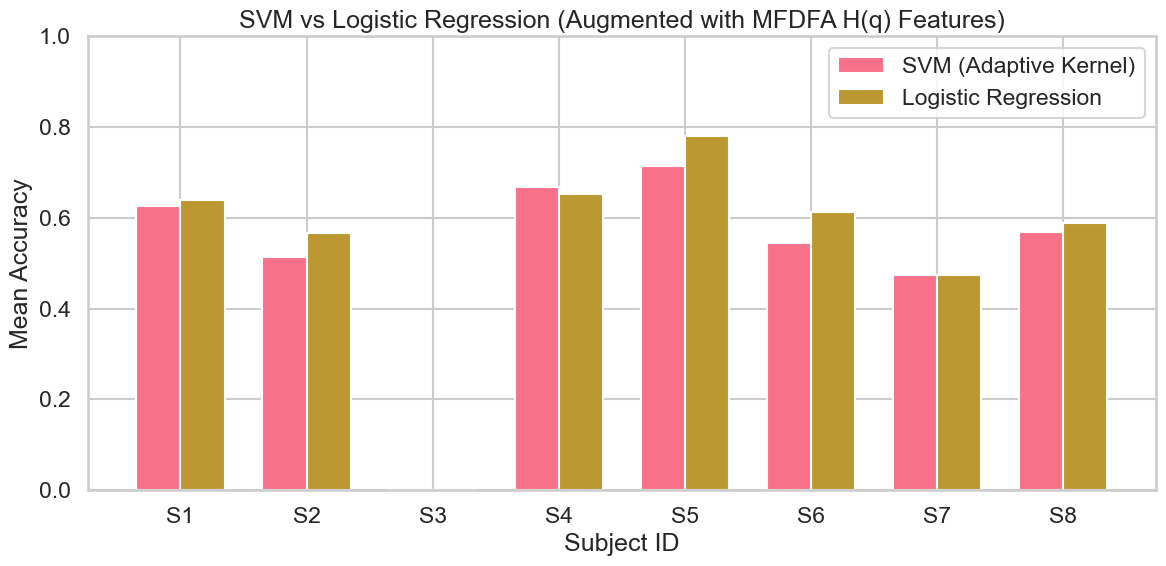

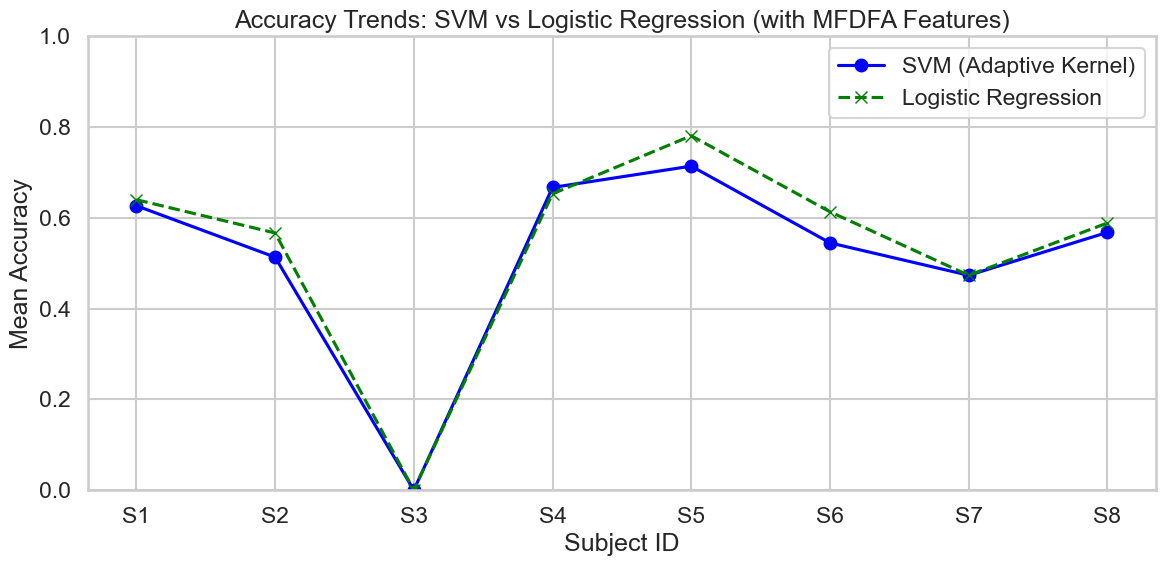

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Step 1: Compute multifractality strength from your existing MFDFA (average across C3/C4)
mfdfa_strength = {}
VAR_THRESH = 0.1  # Threshold for strong multifractality (adjust; e.g., if H(q) range > 0.1, use RBF)
qs = np.arange(-5, 6)

print("Assessing multifractality from MFDFA H(q) for C3 and C4...")
for sid in trials_dict:
    Hq_per_chan = []
    for chan in CHANNELS_OF_INTEREST:
        ch_index = get_channel_index(chaninfo_dict[sid], chan)
        if ch_index is None:
            continue
        sigs = [trial[ch_index, FEEDBACK_START:FEEDBACK_END] for trial in trials_dict[sid] if trial is not None]
        if not sigs:
            continue
        signal = np.concatenate(sigs)
        if len(signal) < MIN_SIGNAL_LEN:
            continue
        signal = highpass(signal)  # Your existing highpass filter
        H = mfdfa(signal)  # Your existing MFDFA function
        Hq_per_chan.append(H)
    
    if Hq_per_chan:
        avg_Hq = np.nanmean(Hq_per_chan, axis=0)
        strength = np.nanmax(avg_Hq) - np.nanmin(avg_Hq)  # Variation (range) as measure of multifractality
        mfdfa_strength[sid] = strength
        print(f"{sid}: H(q) variation (multifractality strength) = {strength:.2f} (strong if > {VAR_THRESH})")
    else:
        mfdfa_strength[sid] = 0
        print(f"{sid}: No valid MFDFA data for multifractality check")

# Step 2: Augmented classification with adaptive kernel (integrates with your LogReg/SVM functions)
svm_means = []
logreg_means = []
AUGMENT_WITH_HQ = True  # Set to True to add H(q) as features; False for alpha power only

print("\nRunning classifications with adaptive SVM kernel based on multifractality...")
for sid in subject_ids:
    features = []
    labels = []
    for i, tr in enumerate(trials_dict[sid]):
        if i >= len(trial_data_dict[sid]):
            continue
        td = trial_data_dict[sid][i]
        if td.tasknumber == 1 and td.targetnumber in [1, 2]:  # Your task filter
            feedback = tr[:, FEEDBACK_START:FEEDBACK_END]
            alpha_power = np.mean(np.abs(hilbert(filtfilt(b_alpha, a_alpha, feedback, axis=1)))**2, axis=1)
            
            combined = alpha_power
            if AUGMENT_WITH_HQ:
                # Compute average H(q) across channels for augmentation
                Hq_avg = np.zeros(len(qs))
                num_valid = 0
                for chan in CHANNELS_OF_INTEREST:
                    ch_index = get_channel_index(chaninfo_dict[sid], chan)
                    if ch_index is None:
                        continue
                    sig = tr[ch_index, FEEDBACK_START:FEEDBACK_END]
                    if len(sig) < MIN_SIGNAL_LEN:
                        continue
                    sig = highpass(sig)
                    H = mfdfa(sig)
                    Hq_avg += H
                    num_valid += 1
                if num_valid > 0:
                    Hq_avg /= num_valid
                combined = np.concatenate([alpha_power, Hq_avg])  # Augment features
            
            features.append(combined)
            labels.append(td.targetnumber - 1)
    
    if len(features) < 10:  # Your min_trials threshold
        svm_means.append(0)
        logreg_means.append(0)
        print(f"Skipping {sid}: Insufficient trials ({len(features)})")
        continue
    
    X = np.array(features)
    y = np.array(labels)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Logistic Regression (baseline)
    logreg = LogisticRegression(max_iter=200)
    logreg_scores = cross_val_score(logreg, X_scaled, y, cv=5)
    logreg_means.append(np.mean(logreg_scores))
    
    # Adaptive SVM kernel
    strength = mfdfa_strength.get(sid, 0)
    kernel = 'rbf' if strength > VAR_THRESH else 'linear'  # Use RBF for strong multifractality
    print(f"{sid}: Multifractality strength {strength:.2f} → Using SVM kernel: {kernel}")
    svm = SVC(kernel=kernel, probability=True)
    svm_scores = cross_val_score(svm, X_scaled, y, cv=5)
    svm_means.append(np.mean(svm_scores))

# Step 3: Visualizations (bar and trend graphs, using your existing plot style)
x = np.arange(len(subject_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, svm_means, width, label='SVM (Adaptive Kernel)')
ax.bar(x + width/2, logreg_means, width, label='Logistic Regression')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Mean Accuracy')
ax.set_title('SVM vs Logistic Regression (Augmented with MFDFA H(q) Features)')
ax.set_xticks(x)
ax.set_xticklabels(subject_ids)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(subject_ids, svm_means, marker='o', linestyle='-', color='blue', label='SVM (Adaptive Kernel)')
ax.plot(subject_ids, logreg_means, marker='x', linestyle='--', color='green', label='Logistic Regression')

ax.set_xlabel('Subject ID')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Accuracy Trends: SVM vs Logistic Regression (with MFDFA Features)')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
